<a href="https://colab.research.google.com/github/Akshatha7710/Face-Map/blob/main/FaceMap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install mediapipe==0.10.14 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 21.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.


In [7]:
import os

!wget https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task -O /content/face_landmarker.task

if os.path.exists("/content/face_landmarker.task"):
    print(f"Model ready — {os.path.getsize('/content/face_landmarker.task')/1024/1024:.1f} MB")
else:
    print("FAILED — try the curl method below")

--2026-03-20 18:09:22--  https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task
Resolving storage.googleapis.com (storage.googleapis.com)... 64.233.179.207, 173.194.193.207, 173.194.194.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|64.233.179.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3758596 (3.6M) [application/octet-stream]
Saving to: ‘/content/face_landmarker.task’

/content/face_landm 100%[===================>]   3.58M  --.-KB/s    in 0.04s   

2026-03-20 18:09:22 (95.9 MB/s) - ‘/content/face_landmarker.task’ saved [3758596/3758596]

Model ready — 3.6 MB


Saved: /content/output_face_image_1.jpg


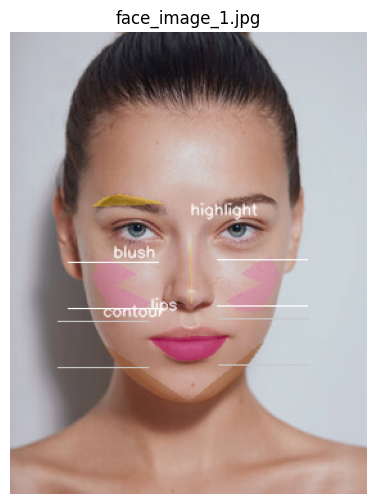

Saved: /content/output_face_image_10.jpeg


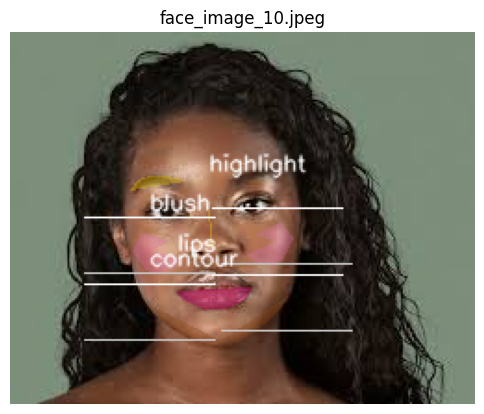

Saved: /content/output_face_image_11.png


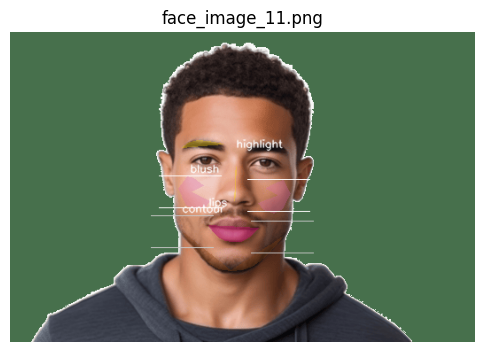

Saved: /content/output_face_image_12.png


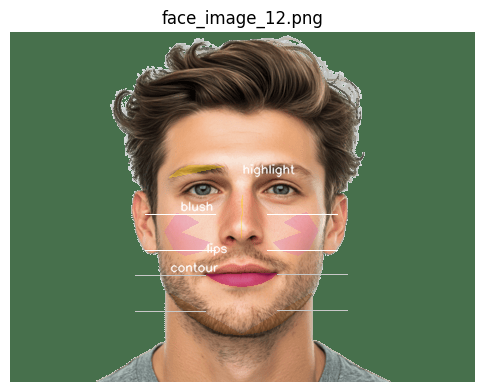

Saved: /content/output_face_image_13.jpeg


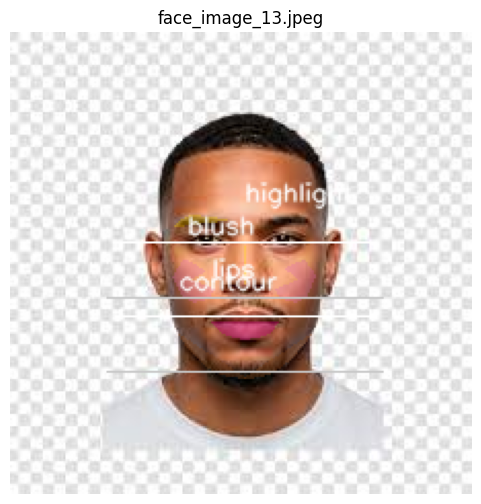

Saved: /content/output_face_image_14.png


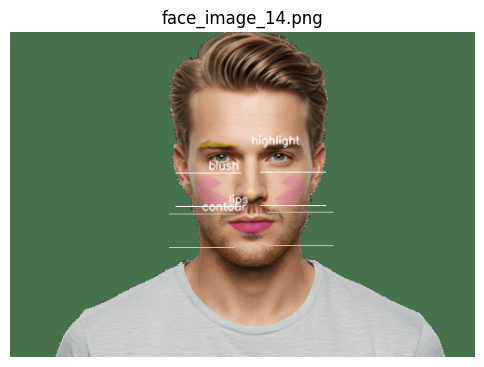

Saved: /content/output_face_image_15.jpg


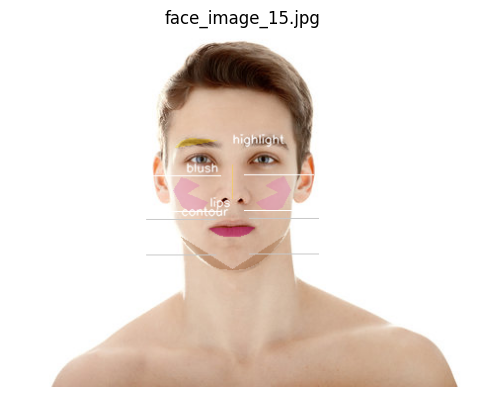

Saved: /content/output_face_image_2.jpg


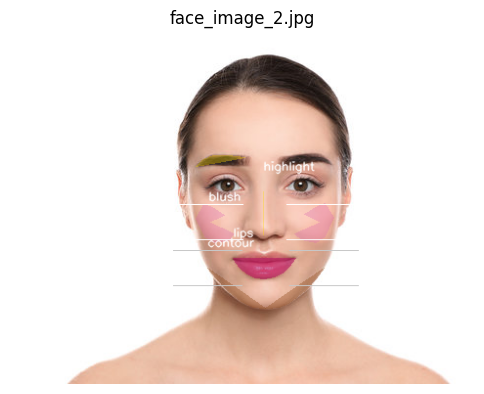

Saved: /content/output_face_image_3.jpeg


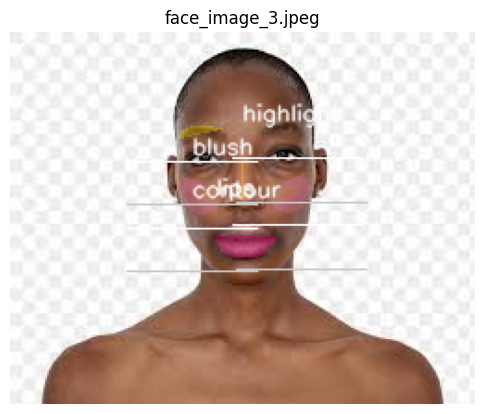

Saved: /content/output_face_image_4.jpeg


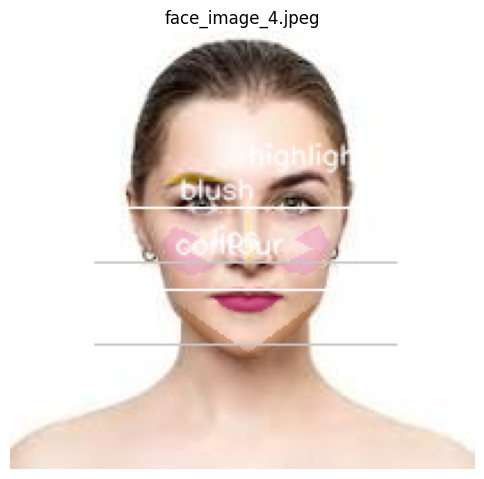

Saved: /content/output_face_image_5.png


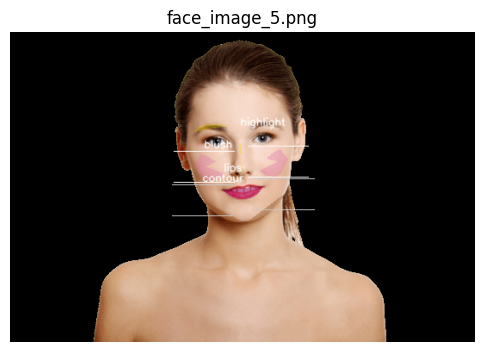

Saved: /content/output_face_image_6.png


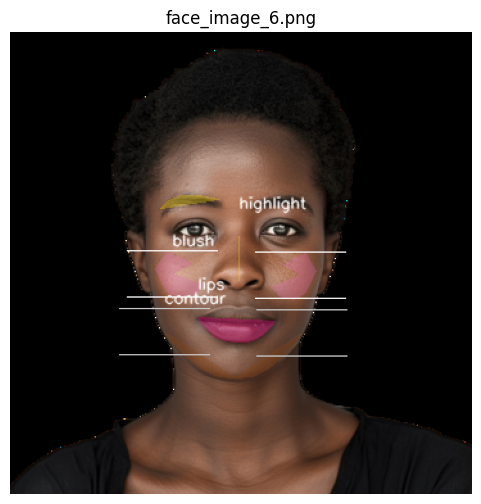

Saved: /content/output_face_image_7.png


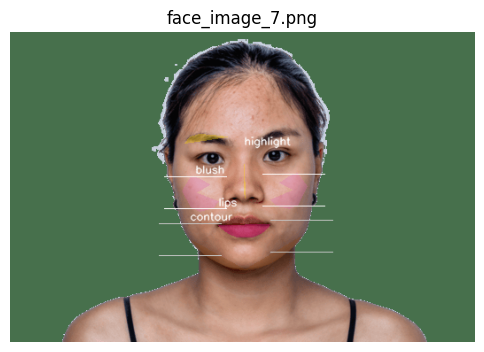

Saved: /content/output_face_image_8.jpg


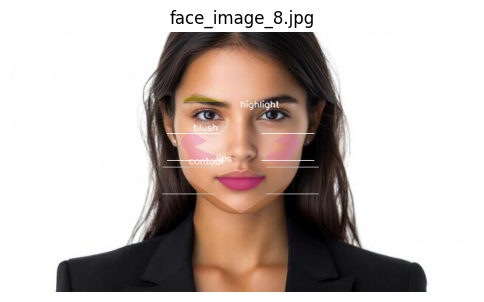

Saved: /content/output_face_image_9.jpg


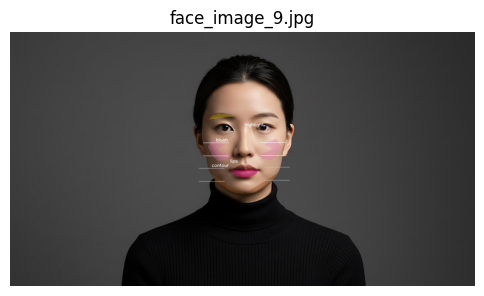

In [14]:
# ── Imports + setup ───────────────────────────────────────────────
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import os

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# ── Makeup zone definitions ───────────────────────────────────────
ZONES = {
    "blush_left":     [50, 101, 118, 117, 123, 187, 207, 206, 203],
    "blush_right":    [280, 330, 347, 346, 352, 411, 427, 426, 423],
    "contour_left":   [172, 136, 150, 149, 176, 148, 152],
    "contour_right":  [397, 365, 379, 378, 400, 377, 152],
    "highlight_nose": [6, 197, 195, 5, 4, 1],
    "highlight_brow": [70, 63, 105, 66, 107],
    "lip_outer":      [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291],
}

# BGR format — gold highlighter, dark pink lipstick
COLORS = {
    "blush_left":     (220, 105,180 , 80),   # soft pink BGR
    "blush_right":    (220, 105, 180, 80),
    "contour_left":   (139,   69, 19, 90),   # dark brown BGR
    "contour_right":  (139,   69, 19, 90),
    "highlight_nose": (255,   215, 0, 90),   # gold BGR
    "highlight_brow": (255,   215, 0, 90),   # gold BGR
    "lip_outer":      (180,  20, 100, 140) # dark pink BGR
}
LABELS = {
    "blush_left":     "blush",
    "contour_left":   "contour",
    "highlight_nose": "highlight",
    "lip_outer":      "lips"
}

# ── Drawing function ──────────────────────────────────────────────
def draw_makeup_zones(image, face_landmarks, h, w):
    for zone_name, indices in ZONES.items():
        points = []
        for idx in indices:
            lm = face_landmarks[idx]
            points.append((int(lm.x * w), int(lm.y * h)))
        pts = np.array(points, dtype=np.int32)

        r, g, b, alpha = COLORS[zone_name]
        overlay = image.copy()
        cv2.fillPoly(overlay, [pts], (b, g, r))
        opacity = alpha / 255.0
        cv2.addWeighted(overlay, opacity, image, 1 - opacity, 0, image)

    # Guide lines above and below blush zones
    for zone_name in ["blush_left", "blush_right"]:
        indices = ZONES[zone_name]
        lm_center = face_landmarks[indices[0]]
        cx, cy = int(lm_center.x * w), int(lm_center.y * h)
        cv2.line(image, (cx - 35, cy - 18), (cx + 35, cy - 18), (255, 255, 255), 1)
        cv2.line(image, (cx - 35, cy + 18), (cx + 35, cy + 18), (255, 255, 255), 1)

    # Guide lines above and below contour zones
    for zone_name in ["contour_left", "contour_right"]:
        indices = ZONES[zone_name]
        lm_center = face_landmarks[indices[0]]
        cx, cy = int(lm_center.x * w), int(lm_center.y * h)
        cv2.line(image, (cx - 35, cy - 18), (cx + 35, cy - 18), (200, 200, 200), 1)
        cv2.line(image, (cx - 35, cy + 18), (cx + 35, cy + 18), (200, 200, 200), 1)

    # Zone labels
    for zone_name, label in LABELS.items():
        if zone_name not in ZONES:
            continue
        indices = ZONES[zone_name]
        lm = face_landmarks[indices[0]]
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.putText(image, label, (cx, cy - 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)

    return image

# ── Run on all images ─────────────────────────────────────────────
options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='/content/face_landmarker.task'),
    running_mode=VisionRunningMode.IMAGE
)

with FaceLandmarker.create_from_options(options) as landmarker:
    for image_path in image_paths:
        image = cv2.imread(image_path)
        if image is None:
            print(f"Skipping (unreadable): {image_path}")
            continue

        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)
        result = landmarker.detect(mp_image)

        if result.face_landmarks:
            h, w, _ = image.shape
            annotated = draw_makeup_zones(image.copy(), result.face_landmarks[0], h, w)

            # Save output
            output_path = f"/content/output_{os.path.basename(image_path)}"
            cv2.imwrite(output_path, annotated)
            print(f"Saved: {output_path}")

            # Display
            plt.figure(figsize=(6, 6))
            plt.title(os.path.basename(image_path))
            plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.show()
        else:
            print(f"No face detected: {os.path.basename(image_path)}")